# Personal Information
Name: **Zoë Oggel**

StudentID: **13383337**

Email: [**zoe.oggel@sutdent.uva.nl**](zoe.oggel@sutdent.uva.nl)

Submitted on: **23.03.2026**

GitHub: https://github.com/Zoe-O16/Thesis.git

### **Data context**

This dataset contains runway review texts from *Style.com* covering the period 2000–2014. Each entry represents a written review of a fashion collection, typically from major fashion weeks (e.g., Paris, Milan, New York, London).
The data captures how collections are described narratively by critics, including references to themes, inspirations, stylistic elements, and brand identity.

### **Data description**

Each row corresponds to a single runway review. The dataset includes both textual content and metadata.
Fields:

* **brand**: fashion house presenting the collection
* **designer**: designer associated with the collection
* **season**: collection season (e.g., Spring/Summer, Fall/Winter)
* **year**: year of the show
* **city**: location of the fashion week
* **author**: reviewer/critic
* **text**: full review text

**Characteristics:**
* Text is unstructured, long-form, and stylistically rich
* Vocabulary includes domain-specific fashion terminology
* Strong variation in length and writing style across reviews
* Temporal span allows longitudinal analysis

**Data quality considerations:**
* Variability in text length and formatting



## Data loading

In [ ]:
from collections import Counter
from itertools import tee

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# NLP / modelling
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Display
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

# Load spaCy model if available
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    nlp = None
    print("spaCy model 'en_core_web_sm' is not installed. Install with: python -m spacy download en_core_web_sm")

# Dataset information
* review length (words, characters)
* Distribution over time, season, city, designer

In [5]:
df = pd.read_csv("stylecom_review_2000s_2014f.csv")

df.shape
df.head()
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6629 entries, 0 to 6628
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        6629 non-null   int64 
 1   season      6629 non-null   object
 2   designer    6629 non-null   object
 3   author      6492 non-null   object
 4   city        6629 non-null   object
 5   date        6629 non-null   object
 6   image       6629 non-null   object
 7   review      6629 non-null   object
 8   Unnamed: 8  5 non-null      object
dtypes: int64(1), object(8)
memory usage: 466.2+ KB


year             0
season           0
designer         0
author         137
city             0
date             0
image            0
review           0
Unnamed: 8    6624
dtype: int64

In [6]:
# Identifying long and short reviews

df["review_char_len"] = df["review"].astype(str).str.len()
df["review_word_len"] = df["review"].astype(str).str.split().str.len()

df["review_char_len"].describe()
df["review_word_len"].describe()


count    6629.000000
mean      225.305928
std        78.447111
min         7.000000
25%       178.000000
50%       219.000000
75%       267.000000
max       721.000000
Name: review_word_len, dtype: float64

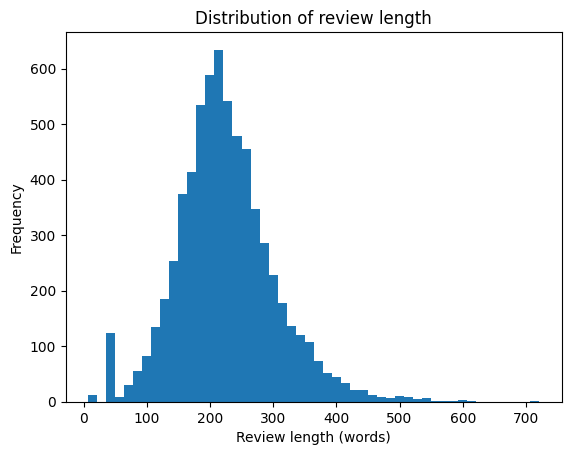

In [7]:
# Plotting review length distribution

plt.hist(df["review_word_len"], bins=50)
plt.xlabel("Review length (words)")
plt.ylabel("Frequency")
plt.title("Distribution of review length")
plt.show()

In [8]:
# Checking for duplicates

df["review"].duplicated().sum()
df[df["review"].duplicated()].head()


,year,season,designer,author,city,date,image,review,Unnamed: 8,review_char_len,review_word_len
529,2002,Fall,Istvan Francer,NaN,PARIS,8-Mar-02,"<div class=""image-container""><a class=""slideshow"" href=""/fashionshows/complete/slideshow/F2002RTW-IFRANCER/#1""><img alt=""Istvan Francer Fall 2002 Ready-to-Wear"" height=""480"" src=""/style/view/34/80...","for more on this designer, click here",NaN,37,7
608,2002,Fall,House of Jazz,NaN,LONDON,18-Feb-02,"<div class=""image-container""><a class=""slideshow"" href=""/fashionshows/complete/slideshow/F2002RTW-HJAZZ/#1""><img alt=""House of Jazz Fall 2002 Ready-to-Wear"" height=""480"" src=""/style/view/84/94/100...","for more on this designer, click here",NaN,37,7
4857,2013,Spring,Fur Fur,NaN,TOKYO,17-Oct-12,"<div class=""image-container""><a class=""slideshow"" href=""/fashionshows/complete/slideshow/S2013RTW-FURFUR/#1""><img alt=""Fur Fur Spring 2013 Ready-to-Wear"" height=""480"" src=""/fashion-shows/spring-20...","We're posting runway pictures from Tokyo fashion week for the first time ever. See the full list of designers here . To read our daily reports on the collections, visit our Style File blog . And d...",NaN,238,43
4911,2013,Spring,Matohu,NaN,TOKYO,15-Oct-12,"<div class=""image-container""><a class=""slideshow"" href=""/fashionshows/complete/slideshow/S2013RTW-MATOHU/#1""><img alt=""Matohu Spring 2013 Ready-to-Wear"" height=""480"" src=""/fashion-shows/spring-201...","We're posting runway pictures from Tokyo fashion week for the first time ever. See the full list of designers here . To read our daily reports on the collections, visit our Style File blog . And d...",NaN,238,43
4912,2013,Spring,Anrealage,NaN,TOKYO,16-Oct-12,"<div class=""image-container""><a class=""slideshow"" href=""/fashionshows/complete/slideshow/S2013RTW-ANREALAGE/#1""><img alt=""Anrealage Spring 2013 Ready-to-Wear"" height=""480"" src=""/fashion-shows/spri...","We're posting runway pictures from Tokyo fashion week for the first time ever. See the full list of designers here . To read our daily reports on the collections, visit our Style File blog . And d...",NaN,238,43


In [9]:
df["year"].value_counts().sort_index()
df["city"].value_counts()
df["designer"].value_counts().head(20)
df["author"].value_counts()
df["season"].value_counts()


season
Fall      3461
Spring    3168
Name: count, dtype: int64

In [10]:
# Checking for corrupted characters in reviews
df["review"].str.contains("�", na=False).sum()
df["review"].str.contains(r"\?", na=False).sum()
df["designer"].value_counts().head(10)

designer
Dolce & Gabbana     52
Michael Kors        32
Burberry Prorsum    31
Ralph Lauren        31
Christian Dior      31
Fendi               31
Giorgio Armani      31
Balenciaga          31
Valentino           31
Marc Jacobs         31
Name: count, dtype: int64

In [11]:
# Inspect punctuation and token complexity in the reviews.

def avg_sentence_length(text):
    sentences = re.split(r"[.!?]", str(text))
    words = str(text).split()
    if len(sentences) == 0:
        return 0
    return len(words) / len(sentences)

df["avg_sentence_len"] = df["review"].apply(avg_sentence_length)

df["avg_sentence_len"].describe()

count    6629.000000
mean       16.256737
std         3.551870
min         2.500000
25%        13.909091
50%        16.090909
75%        18.461538
max        29.857143
Name: avg_sentence_len, dtype: float64

In [12]:

tokens = " ".join(df["review"].astype(str)).lower().split()
counter = Counter(tokens)

counter.most_common(50)

[('the', 79502),
 ('a', 54019),
 ('and', 44880),
 ('of', 41429),
 ('to', 27472),
 ('in', 26946),
 ('with', 22163),
 ('that', 18219),
 ('was', 17406),
 ('for', 13904),
 ('on', 11646),
 ('as', 10035),
 ('it', 9638),
 ('his', 9194),
 ('but', 8895),
 ('were', 8723),
 ('this', 7567),
 ('is', 7201),
 ('her', 7120),
 ('at', 6799),
 ('an', 6478),
 ('from', 6172),
 ('he', 5946),
 ('like', 4937),
 ('by', 4914),
 ('collection', 4721),
 ('there', 4614),
 ('or', 4356),
 ('be', 4333),
 ('more', 4274),
 ('she', 4180),
 ('one', 3941),
 ('into', 3718),
 ('they', 3698),
 ('all', 3642),
 ('their', 3636),
 ('has', 3558),
 ('have', 3495),
 ('had', 3488),
 ('black', 3321),
 ('new', 3286),
 ('up', 3247),
 ('out', 3206),
 ('show', 3161),
 ('dresses', 3056),
 ('not', 2964),
 ('which', 2860),
 ('been', 2723),
 ('designer', 2715),
 ('you', 2704)]

In [13]:
[x for x in counter.most_common(200) if "80" in x[0]]
[x for x in counter.most_common(200) if "silk" in x[0]]
[x for x in counter.most_common(200) if "denim" in x[0]]

[]

In [14]:
#Check whether the dataset includes multiple reviews per show or designer.

df.groupby(["designer","year","season"]).size().sort_values(ascending=False).head()

designer         year  season
Michael Kors     2014  Fall      3
Saint Laurent    2014  Fall      2
Dolce & Gabbana  2004  Fall      2
                 2010  Spring    2
                       Fall      2
dtype: int64

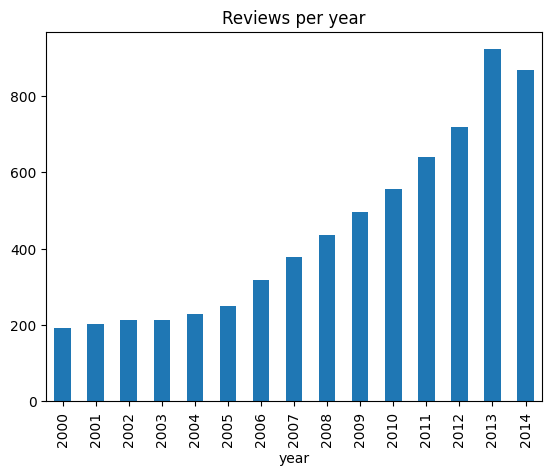

In [15]:
# time distrubution of reviews

df["year"].value_counts().sort_index().plot(kind="bar")
plt.title("Reviews per year")
plt.show()

In [16]:
df.groupby("year")["review_word_len"].mean()

year
2000    117.119171
2001    143.980392
2002    172.154930
2003    209.234742
2004    225.794760
2005    219.406375
2006    225.962145
2007    212.416887
2008    214.655963
2009    210.133333
2010    232.643243
2011    252.654147
2012    243.426778
2013    228.606949
2014    263.176471
Name: review_word_len, dtype: float64

In [17]:
df.groupby("season")["review_word_len"].mean()


season
Fall      229.186073
Spring    221.066919
Name: review_word_len, dtype: float64

In [18]:
df.groupby("city")["review_word_len"].mean()

#cities look weird?


city
BERLIN                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

# Verbs EDA


In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r"<.*?>", " ", text)  # remove HTML
    text = re.sub(r"\s+", " ", text)    # normalize whitespace
    return text.strip()

df["clean_review"] = df["review"].apply(clean_text)

In [20]:
# Extract verbs
verb_counter = Counter()

for doc in nlp.pipe(df["clean_review"], batch_size=50):
    for token in doc:
        if token.pos_ == "VERB":
            lemma = token.lemma_.lower()
            verb_counter[lemma] += 1

In [21]:
verb_df = pd.DataFrame(verb_counter.items(), columns=["verb", "count"])
verb_df = verb_df.sort_values(by="count", ascending=False)

print(len(verb_df))
verb_df.tail(10)

# note questions marks: improve cleaning!

6550


,verb,count
4003,that?nice,1
4004,were?looked,1
4005,squat,1
4006,scott?known,1
4009,pardon,1
4010,s.,1
4011,hunger,1
4015,bewimple,1
4016,cave,1
6549,hazard,1


In [22]:
verb_df.head(10)


,verb,count
51,have,4785
4,be,4772
66,make,4585
76,look,3895
21,say,3226
11,wear,3052
10,come,2917
123,do,2517
111,go,2205
12,show,2178


In [23]:
verb_df.to_csv("verb_counts.csv", index=False)

In [24]:
weak_verbs = {"be", "have", "do"}
verb_df = verb_df[~verb_df["verb"].isin(weak_verbs)]

## Topic modelling

In [25]:
# Prepare text for topic modelling
text_col = "review" if "review" in df.columns else None

if text_col is None:
    print("No 'text' column found. Update text_col to the correct column name.")
else:
    texts = df[text_col].dropna().astype(str)
    vectorizer = CountVectorizer(
        max_df=0.9,
        min_df=5,
        stop_words="english"
    )
    X = vectorizer.fit_transform(texts)
    print(X.shape)

(6629, 14395)


In [26]:
# Train LDA baseline
if "X" in globals():
    lda = LatentDirichletAllocation(n_components=10, random_state=42)
    lda.fit(X)
    print("LDA fitted.")

LDA fitted.


In [27]:
# Inspect top words per topic
def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx}: {', '.join(words)}")

if "lda" in globals() and "vectorizer" in globals():
    feature_names = vectorizer.get_feature_names_out()
    print_topics(lda, feature_names, n_top_words=10)

Topic 0: collection, like, fashion, designer, clothes, today, way, time, season, new
Topic 1: collection, like, clothes, dress, designer, fashion, just, pieces, runway, season
Topic 2: dresses, collection, cavalli, yamamoto, black, like, owens, new, leather, designer
Topic 3: collection, black, like, fashion, dresses, season, way, new, designer, white
Topic 4: black, collection, like, dress, dresses, silk, designer, season, skirt, red
Topic 5: collection, dress, like, said, clothes, dresses, new, season, black, looks
Topic 6: collection, dress, silk, designer, like, style, black, skirt, season, dresses
Topic 7: dresses, collection, skirts, jackets, coats, like, white, season, chiffon, leather
Topic 8: collection, dresses, season, new, like, black, designer, said, white, runway
Topic 9: collection, leather, dresses, new, like, black, designer, season, jackets, pants


Note: Topic Filtering is needed! Haven't had the time


## Topic distribution per document

In [28]:
if "lda" in globals() and "X" in globals():
    topic_dist = lda.transform(X)
    df_topics = pd.DataFrame(topic_dist, columns=[f"topic_{i}" for i in range(topic_dist.shape[1])])

    df_reset = df.reset_index(drop=True).copy()
    text_mask = df_reset[text_col].notna() if text_col in df_reset.columns else pd.Series([False] * len(df_reset))

    # Align topic rows back to original dataframe
    for col in df_topics.columns:
        df_reset[col] = np.nan
    df_reset.loc[text_mask, df_topics.columns] = df_topics.values

    df = df_reset
    df[df_topics.columns].head()

## Topic trends over time

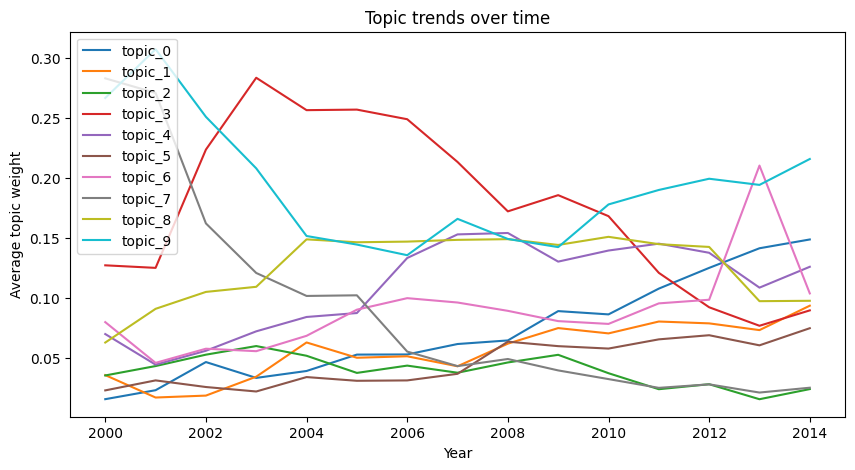

In [29]:
topic_cols = [c for c in df.columns if c.startswith("topic_")]

if "year" in df.columns and len(topic_cols) > 0:
    topic_over_time = df.groupby("year")[topic_cols].mean()
    topic_over_time.plot(figsize=(10, 5), title="Topic trends over time")
    plt.xlabel("Year")
    plt.ylabel("Average topic weight")
    plt.show()
else:
    print("Need 'year' column and topic columns.")